# 실습06_딥러닝-연예인 분류기

직접 수집한 연예인 사진을 이용해 CNN 분류기를 만들어봅니다.

이번 노트북의 목표는 다음과 같습니다.

- `bing_image_downloader`로 이미지 데이터를 수집합니다.
- `ImageFolder`를 이용해 폴더 이름을 클래스 라벨로 사용합니다.
- 모든 데이터에 동일한 크기 조정과 정규화 전처리를 적용합니다.
- 작은 CNN 모델을 만들어 4명의 연예인을 분류합니다.
- 학습된 모델로 테스트 데이터와 직접 준비한 이미지를 예측합니다.

## 0. 코랩 한글 패치

In [ ]:
# Colab 한글 폰트 설정
# 이 셀을 먼저 실행하면 matplotlib 그래프의 한글이 깨지지 않습니다.
!sudo apt-get -qq install fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print("한글 폰트 설정 완료")

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share

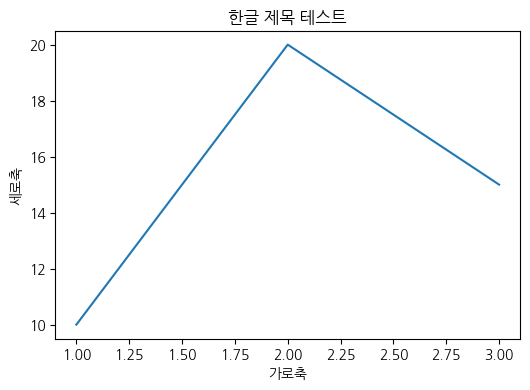

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3], [10, 20, 15])
plt.title("한글 제목 테스트")
plt.xlabel("가로축")
plt.ylabel("세로축")
plt.show()

## 1. 데이터 수집

`bing_image_downloader`를 이용해 검색어별 이미지를 다운로드합니다.

다운로드된 이미지는 다음 구조로 저장됩니다.

```text
./data/celeb/강호동/
./data/celeb/차은우/
./data/celeb/이수지/
./data/celeb/카리나/
```

- 구글 마운트

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.1 라이브러리 설치

아래 셀은 설치가 필요한 경우에만 주석을 해제하고 한 번 실행합니다.

In [ ]:
# 설치가 필요한 경우 아래 주석을 해제하고 실행합니다.
%pip install bing_image_downloader

### 1.2 이미지 다운로드

검색어별 이미지를 다운로드하면 `./data/celeb/검색어/` 형태의 폴더가 만들어집니다.

이미 이미지가 충분히 있는 클래스는 건너뛰고, 부족한 클래스만 추가로 다운로드합니다. 더 정확한 사진을 모으고 싶다면 검색어에 `배우`, `가수`, `방송인` 같은 단어를 붙여 조정할 수 있습니다.


In [ ]:
# Bing 이미지 검색 결과를 내려받기 위한 downloader를 불러옵니다.
from bing_image_downloader import downloader

# 폴더 이름이 곧 클래스 이름으로 사용됩니다.
queries = ['강호동', '차은우', '이수지', '카리나']
for q in queries:
    # 검색어마다 최대 60장의 이미지를 ./data/celeb/검색어/ 폴더에 저장합니다.
    downloader.download(q, limit=60, output_dir='./data/celeb',
                        adult_filter_off=True, timeout=60)

## 2. 환경 준비

이미지 파일을 다루기 위한 라이브러리, PyTorch 학습에 필요한 라이브러리, 학습 장치를 준비합니다.

In [ ]:
# 파일 경로를 다루기 위한 표준 라이브러리입니다.
import os
from pathlib import Path

# 이미지 로딩과 시각화에 사용합니다.
from PIL import Image

# PyTorch 모델 학습에 필요한 라이브러리입니다.
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder

# 데이터 분할과 평가 지표 계산에 사용합니다.
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# GPU가 있으면 cuda를, 없으면 CPU를 사용합니다.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"사용 device: {device}")

사용 device: cuda


## 3. 데이터 로드와 전처리

Bing에서 받은 이미지 중에는 손상된 파일이나 이미지가 아닌 파일이 섞일 수 있습니다. 먼저 사용할 수 없는 파일을 정리한 뒤 `ImageFolder`로 데이터를 불러옵니다.

이 노트북은 모든 데이터에 고정 전처리만 적용합니다. 이미지를 `128x128` 크기로 맞추고, 텐서 변환과 정규화만 수행합니다.

### 3.1 손상 이미지 정리

In [ ]:
# @title
'''
# 코랩에서 시간 오래거리고 에러발생
# 이미지가 저장된 최상위 폴더입니다. 하위 폴더명이 클래스 이름이 됩니다.
data_dir = Path("./data/celeb")
# 학습에 사용할 이미지 확장자만 남깁니다.
valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

# 이미지 다운로드를 먼저 하지 않았다면 여기서 실행을 멈춥니다.
if not data_dir.exists():
    raise FileNotFoundError("./data/celeb 폴더가 없습니다. 먼저 이미지 다운로드 셀을 실행하세요.")

removed = 0
# 클래스 폴더를 하나씩 확인합니다.
for class_dir in data_dir.iterdir():
    if not class_dir.is_dir():
        continue

    # 폴더 안의 파일이 실제 이미지인지 검사합니다.
    for fp in class_dir.iterdir():
        if not fp.is_file():
            continue

        # 허용하지 않는 확장자의 파일은 삭제합니다.
        if fp.suffix.lower() not in valid_exts:
            fp.unlink(missing_ok=True)
            removed += 1
            continue

        # 확장자는 이미지처럼 보여도 파일이 깨져 있을 수 있으므로 PIL로 열어 검증합니다.
        try:
            with Image.open(fp) as img:
                img.verify()
        except Exception:
            fp.unlink(missing_ok=True)
            removed += 1

print(f"삭제한 파일 수: {removed}")
'''

### 3.2 학습/평가 Transform과 ImageFolder

- 학습, 검증, 테스트, 직접 예측에 모두 같은 고정 전처리를 사용합니다.
- 전처리는 `Resize -> ToTensor -> Normalize` 순서입니다.
- `ImageFolder`는 하위 폴더명을 클래스 라벨로 자동 사용합니다.

In [ ]:
# transform: 크기 통일 + 텐서 변환 + 정규화
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

# loader: 모든 이미지를 RGB로 강제 (RGBA 섞이는 것 방지)
dataset = ImageFolder(
    root='./drive/MyDrive/data_new',
    transform=transform,
    loader=lambda p: Image.open(p).convert('RGB'),
)
print('총 이미지 수:', len(dataset))
print('클래스:', dataset.class_to_idx)

총 이미지 수: 238
클래스: {'강호동': 0, '이수지': 1, '차은우': 2, '카리나': 3}


### 3.3 학습/검증/테스트 데이터 분할

전체 데이터를 `train:validation:test = 8:1:1` 비율로 나눕니다. 클래스 비율이 최대한 유지되도록 `stratify`를 사용합니다.

학습, 검증, 테스트 subset은 같은 이미지 인덱스 기준으로 나뉘며, 모두 고정 전처리된 이미지를 사용합니다. 검증 데이터는 학습 중 `val_loss`와 `val_acc`를 확인하는 용도로 사용합니다.

In [ ]:
# 8:2로 train/test 분할
train_idx, test_idx = train_test_split(
    list(range(len(dataset))),
    test_size=0.2,
    random_state=42,
    stratify=dataset.targets,
)
train_set = Subset(dataset, train_idx)
test_set = Subset(dataset, test_idx)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
test_loader = DataLoader(test_set, batch_size=8, shuffle=False)
print(f'Train: {len(train_set)}장, Test: {len(test_set)}장')

Train: 190장, Test: 48장


### 3.4 첫 번째 학습 배치 확인

모델에 들어가는 이미지 텐서의 shape과 라벨 shape을 확인합니다.

In [ ]:
# DataLoader에서 첫 번째 batch만 꺼내 입력/정답 텐서 모양을 확인합니다.
for x, y in train_loader:
    print(f"Shape of x [batch, channel, height, width]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    print("첫 번째 배치 라벨:", y)
    # 한 batch만 확인하면 되므로 반복문을 바로 종료합니다.
    break

Shape of x [batch, channel, height, width]: torch.Size([8, 3, 128, 128])
Shape of y: torch.Size([8]) torch.int64
첫 번째 배치 라벨: tensor([0, 1, 0, 1, 0, 0, 2, 3])


## 4. CNN 모델

입력 이미지는 `(3, 128, 128)` 형태입니다. Conv 블록을 3개 쌓으면 공간 크기가 `128 -> 64 -> 32 -> 16`으로 줄어듭니다.

마지막에는 `Flatten` 후 `Linear` layer를 연결해 클래스 개수만큼 출력합니다.


In [ ]:
# ImageFolder가 찾은 클래스 개수만큼 마지막 출력 노드를 만듭니다.
num_classes = 4

# 간단한 CNN 모델
model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    # 128x128 -> 64x64
    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    # 64x64 -> 32x32
    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    # 32x32 -> 16x16
    nn.MaxPool2d(kernel_size=2),

    nn.Flatten(),
    nn.Linear(128 * 16 * 16, 256),
    nn.ReLU(),
    nn.Linear(256, num_classes),
).to(device)

print(model)


Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=32768, out_features=256, bias=True)
  (11): ReLU()
  (12): Linear(in_features=256, out_features=4, bias=True)
)


## 5. 학습

다중 분류 문제이므로 손실 함수는 `CrossEntropyLoss`를 사용합니다. 옵티마이저는 `Adam`을 사용합니다.

매 epoch마다 학습 데이터로 모델을 업데이트하고, 검증 데이터로 `val_loss`와 `val_acc`를 확인합니다.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss, correct = 0.0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
    print(f'Epoch {epoch+1:02d} | loss {total_loss/len(train_set):.3f} | acc {correct/len(train_set):.2f}')

Epoch 01 | loss 1.448 | acc 0.22
Epoch 02 | loss 1.319 | acc 0.37
Epoch 03 | loss 1.175 | acc 0.50
Epoch 04 | loss 1.113 | acc 0.51
Epoch 05 | loss 0.984 | acc 0.58
Epoch 06 | loss 0.814 | acc 0.65
Epoch 07 | loss 0.661 | acc 0.76
Epoch 08 | loss 0.577 | acc 0.75
Epoch 09 | loss 0.441 | acc 0.82
Epoch 10 | loss 0.303 | acc 0.92
Epoch 11 | loss 0.165 | acc 0.95
Epoch 12 | loss 0.222 | acc 0.95
Epoch 13 | loss 0.158 | acc 0.94
Epoch 14 | loss 0.086 | acc 0.95
Epoch 15 | loss 0.093 | acc 0.96
Epoch 16 | loss 0.049 | acc 0.98
Epoch 17 | loss 0.010 | acc 1.00
Epoch 18 | loss 0.007 | acc 1.00
Epoch 19 | loss 0.006 | acc 1.00
Epoch 20 | loss 0.002 | acc 1.00


## 6. 테스트 성능 평가

학습에 사용하지 않은 테스트 데이터로 모델 성능을 확인합니다.

In [ ]:
model.eval()
correct = 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
print(f'Test 정확도: {correct/len(test_set):.2f}')

Test 정확도: 0.54


## 7. 내 사진으로 시험

같은 폴더에 테스트할 이미지를 넣고 `test_image_path`만 바꿔서 실행합니다. 직접 예측할 때도 학습/평가와 같은 고정 전처리를 사용합니다.

예측: 차은우


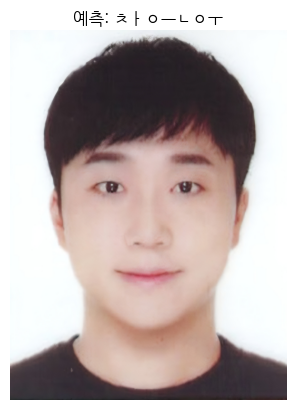

In [15]:
test_image_path = '나.jpg'

img = Image.open(test_image_path).convert('RGB')
x = transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    pred_idx = model(x).argmax(1).item()

classes = list(dataset.class_to_idx.keys())
print('예측:', classes[pred_idx])

plt.imshow(img)
plt.title(f'예측: {classes[pred_idx]}')
plt.axis('off')
plt.show()

## 정리

- 검색어별 이미지 폴더를 만들면 `ImageFolder`가 폴더 이름을 그대로 라벨로 사용합니다.
- RGB 이미지를 사용하므로 CNN 입력 채널 수는 3입니다.
- 모든 데이터에는 `Resize`, `ToTensor`, `Normalize`만 적용합니다.
- 4명 분류 문제이므로 출력 노드 수는 클래스 개수와 같아야 합니다.
- 데이터 수가 적으면 학습 정확도는 빠르게 높아질 수 있지만 테스트 정확도는 불안정할 수 있습니다.
- 성능을 높이려면 데이터를 더 모으거나 사전 학습 모델을 활용할 수 있습니다.